In [4]:
# Importing things I need
import scirpy as ir
import scanpy as sc
from glob import glob
import pandas as pd
import tarfile
import anndata
import warnings
import scanpy as sc
import anndata as an
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Putting together TCR metadata & justification for label transfer of proilferating T cells

In [5]:
# TCR metadata was compiled by manually combining the contig annotations csv for each patient's timepoint 
# (e.g. Pt10 D01) with the cell barcode from the scRNAseq. All cells were required to have at least 1 TCR alpha
# 1 TCR Beta sequence.
# raw spreadsheet is linked 

In [6]:
# importing cd8 dataframes and tcr dataframes
cd8_pre_label_transfer = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/HC_Tclus/cd8t_quick_cluster2.csv', sep=',')
cd8_post_label_transfer = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/HC_Tclus/cd8_post_label_transfer.csv', sep = ',')
filtered_all_tcr = pd.read_csv("gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/meta_patient_TCRs/filtered_all_tcr_042025.csv", sep = ',')


/tmp/ipykernel_119/2457433890.py:4: DtypeWarning: Columns (23,24,25,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  filtered_all_tcr = pd.read_csv("gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/meta_patient_TCRs/filtered_all_tcr_042025.csv", sep = ',')


In [7]:
# the barcode/cell_id is identical from scRNAseq and scTCRseq: however, after the dash  differs. 
# From here on out, TCRs and cells are matched based on barcode/cell_id AND the specimenID.
def splice_id_v1(df):
    df['cell_id'] = df['cell_id'].str.split('-').str[0]
    return df
cd8_pre_lt_meta = (splice_id_v1(cd8_pre_label_transfer))
cd8_post_lt_meta = (splice_id_v1(cd8_post_label_transfer))

filtered_all_tcr['barcode'] = filtered_all_tcr['barcode'].str.split('-').str[0]

In [8]:
# merge cd8 metadata with tcr metadata after the splicing
matching_cells_pre_lt = pd.merge(
    cd8_pre_lt_meta,
    filtered_all_tcr,
    left_on=['cell_id', 'specimenID'],
    right_on=['barcode', 'patient 10x channel'], 
    how='inner'
)

matching_cells_post_lt = pd.merge(
    cd8_post_lt_meta,
    filtered_all_tcr,
    left_on=['cell_id', 'specimenID'],  
    right_on=['barcode', 'patient 10x channel'],  
    how='inner'
)

In [10]:
# importing dataframe for all T cells, subsetting to proiferating T cells and match TCRs accordingly
t_all = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/HC_Tclus/t_l1_cluster.csv', sep = ',')
prolif_t = t_all[t_all['humap_fgraph_res.0.1'] == 3]

def splice_id(df):
    df['cell_id'] = df['cell_id'].str.split('-').str[0]
    return df
prolif_t_meta = (splice_id(prolif_t))

matching_cells_prolif_T = pd.merge(
    prolif_t_meta,
    filtered_all_tcr,
    left_on=['cell_id', 'specimenID'],  # Columns from cd8_post_lt_meta
    right_on=['barcode', 'patient 10x channel'],  # Columns from meta_intra_tcr
    how='inner'
)

/tmp/ipykernel_119/499288715.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cell_id'] = df['cell_id'].str.split('-').str[0]


In [16]:
# Generating umap showing strong clonal overlap with the proliferating cluster

filter_values = [4,7,8] # we're interested in the activated T cell clusters [4,7,8] 
activated_cells_pre_lt = matching_cells_pre_lt[matching_cells_pre_lt['sub_humap_fgraph_res.1'].isin(filter_values)]

subset_matching_TCR = matching_cells_prolif_T[
    matching_cells_prolif_T.set_index(['specimenID', 'cdr3_beta']).index.isin(
        activated_cells_pre_lt.set_index(['specimenID', 'cdr3_beta']).index
    )
]

# plot the TCRs
plt.figure(figsize=(176, 128))
t_clusters = [matching_cells_prolif_T[matching_cells_prolif_T['humap_fgraph_res.0.1'] == i] for i in range(4)]
for i, t_clusters in enumerate(t_clusters):
    plt.scatter(t_clusters.iloc[:, 90], t_clusters.iloc[:, 91], s=2500, c= 'gray', edgecolors='none')
    plt.scatter(subset_matching_TCR.iloc[:, 90], subset_matching_TCR.iloc[:, 91], s=3000, c='red',marker='^')

plt.savefig("prolif_Tumap_with_act_cd8_TCR.pdf", format="pdf", bbox_inches="tight")
# plt.show()
plt.close()

In [18]:
# Since demonstrating strong clonal overlap we then performed label transfer (see label transfer code from Hongcheng Yao)
# we can perform similar filtering on the new matching_cells_post_lt dataframe

filter_values = [4,7,8] # we're interested in the activated T cell clusters [4,7,8] 
activated_cells_post_lt = matching_cells_post_lt[matching_cells_post_lt['transferCd8tCellType'].isin(filter_values)]

act_post_lt_pre = activated_cells_post_lt[activated_cells_post_lt['treatment'] == 'Pre']
act_post_lt_on = activated_cells_post_lt[activated_cells_post_lt['treatment'] == 'On']

act_cd8_post_lt_g6 = activated_cells_post_lt[activated_cells_post_lt['PFSmo'] > 6]
act_cd8_post_lt_l6 = activated_cells_post_lt[activated_cells_post_lt['PFSmo'] <= 6]

act_g6_pre_post_lt =  act_post_lt_pre[act_post_lt_pre['PFSmo'] > 6]
act_g6_on_post_lt = act_post_lt_on[act_post_lt_on['PFSmo'] > 6]
act_l6_pre_post_lt = act_post_lt_pre[act_post_lt_pre['PFSmo'] <= 6]
act_l6_on_post_lt = act_post_lt_on[act_post_lt_on['PFSmo'] <= 6]

In [19]:
# Some exploration to see the number of cells with TCRs on a per specimen basis and the proportion of those 
# cells that reside in the activated clusters

activated_counts = activated_cells_post_lt.groupby('specimenID').size().reset_index(name='activated_count')
matching_counts = matching_cells_post_lt.groupby('specimenID').size().reset_index(name='total_count')

# Merge the two dataframes on 'specimenID'
fraction_df = pd.merge(activated_counts, matching_counts, on='specimenID', how='left')

# Calculate the fraction of activated cells
fraction_df['fraction'] = fraction_df['activated_count'] / fraction_df['total_count']

# Display the resulting dataframe
print(fraction_df)

   specimenID  activated_count  total_count  fraction
0      P02D01                9           18  0.500000
1      P02D15               96          244  0.393443
2      P03D01                1           21  0.047619
3      P03D15               13           29  0.448276
4      P10D01                1           27  0.037037
5      P10D15               18           86  0.209302
6      P11D01              115          264  0.435606
7      P11D15              128          368  0.347826
8      P13D01               11           38  0.289474
9      P13D15                6           38  0.157895
10     P14D01                7           16  0.437500
11     P14D15               14           21  0.666667
12     P15D01                2            8  0.250000
13     P17D01              180         1030  0.174757
14     P17D15              119          466  0.255365
15     P18D01                9           84  0.107143
16     P18D15              624         1057  0.590350
17     P19D01              1

# Fig 4A


Per-patient fractions table (used for Wilcoxon tests)

   patient         group  D01_total_clones  D15_total_clones  \
0      P19  nonresponder               184               187   
1      P25  nonresponder               283               400   
2      P27  nonresponder               484               728   
3      P28  nonresponder               272                57   
4      P29  nonresponder               816               477   
5      P30  nonresponder               306               202   
6      P33  nonresponder               480               148   
7      P36  nonresponder               222                83   
8      P02     responder                15               143   
9      P10     responder                19                71   
10     P11     responder               148               258   
11     P13     responder                25                33   
12     P17     responder               432               283   
13     P18     responder                62      

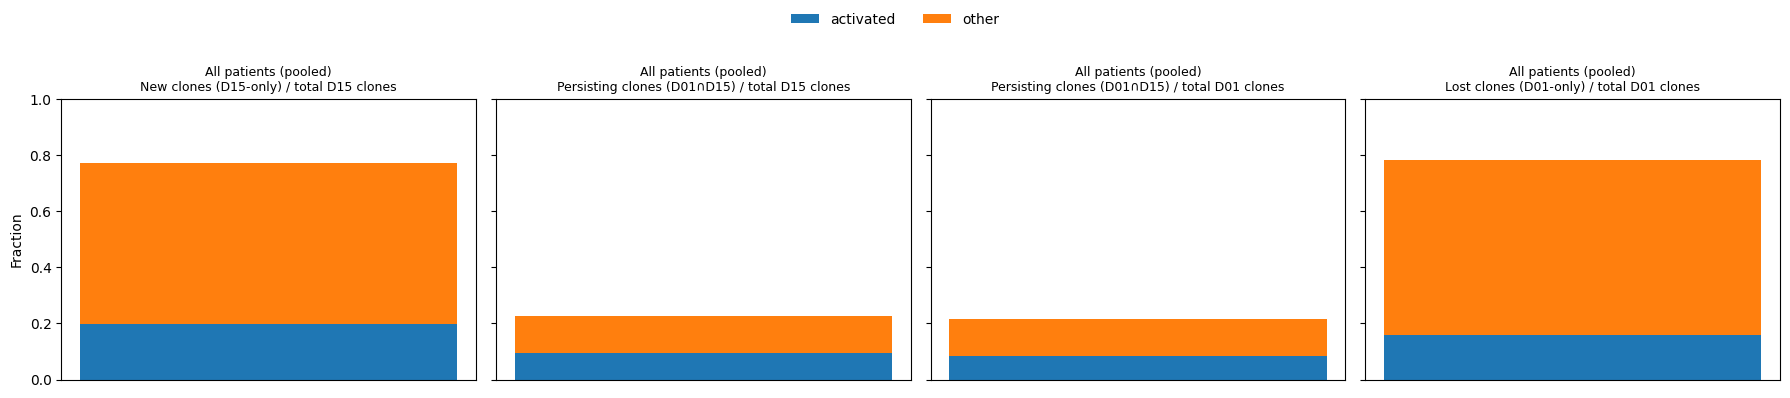

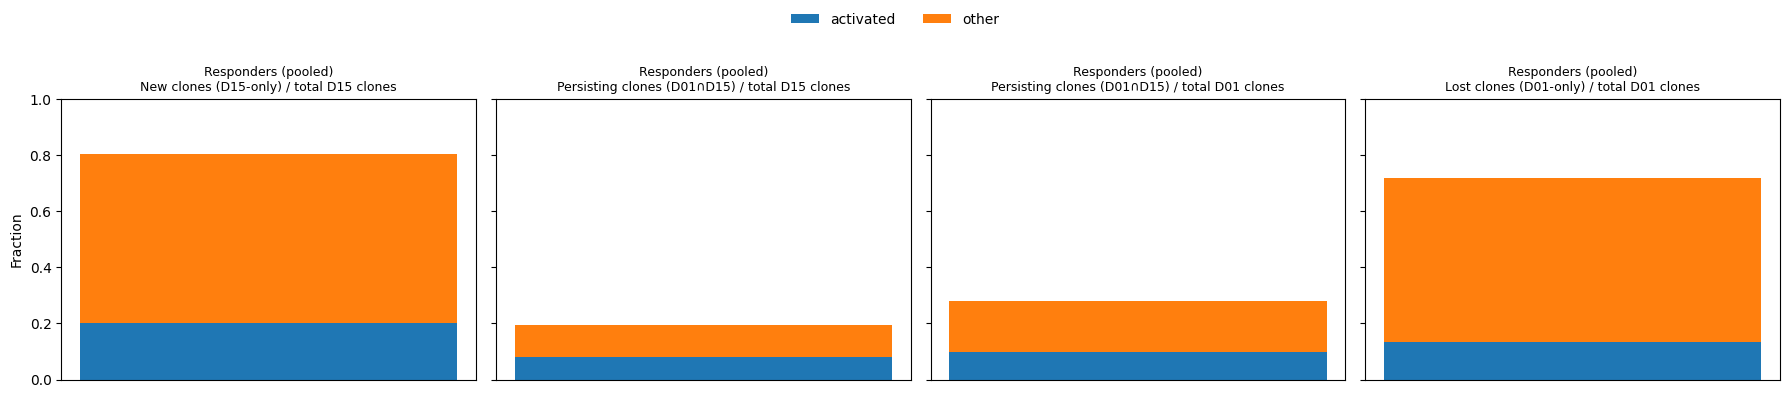

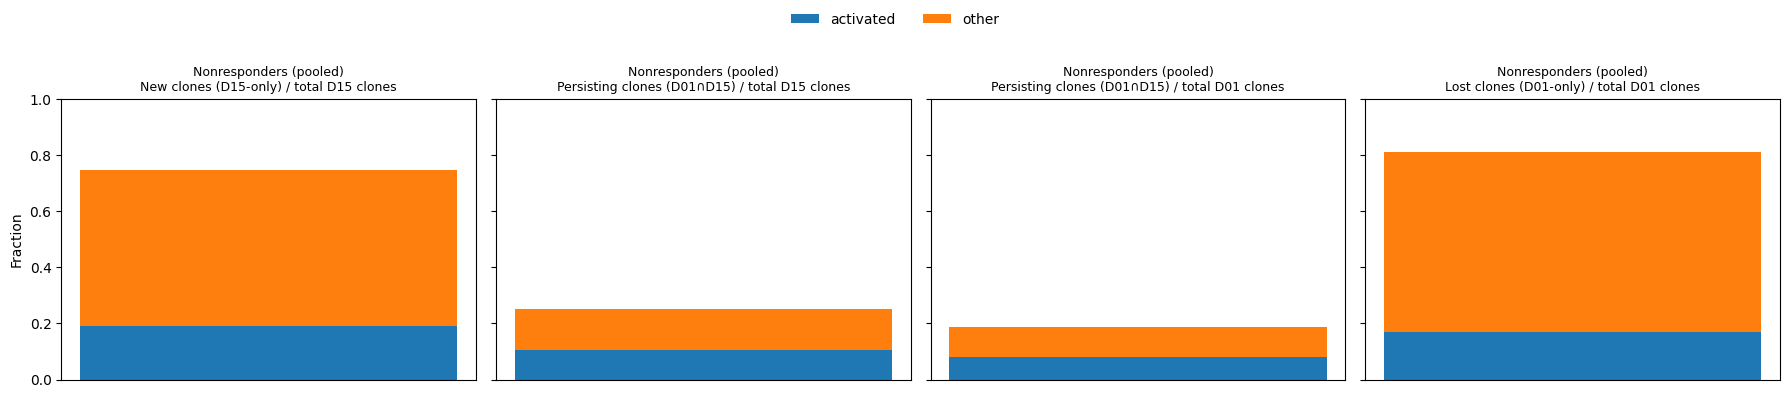


Wrote: CD8_post_LT_pooled_bar_fractions.csv

Wilcoxon paired tests within ALL patients: activated fraction vs other fraction (paired within patient)

    new_of_D15 | n=18 | p=2.288818359375e-05
persist_of_D15 | n=18 | p=0.00067138671875
persist_of_D01 | n=18 | p=0.00400543212890625
   lost_of_D01 | n=18 | p=7.62939453125e-06

Wilcoxon paired tests within RESPONDERS: activated fraction vs other fraction (paired within patient)

    new_of_D15 | n=10 | p=0.001953125
persist_of_D15 | n=10 | p=0.037109375
persist_of_D01 | n=10 | p=0.01953125
   lost_of_D01 | n=10 | p=0.001953125

Wilcoxon paired tests within NONRESPONDERS: activated fraction vs other fraction (paired within patient)

    new_of_D15 | n= 8 | p=0.0234375
persist_of_D15 | n= 8 | p=0.0078125
persist_of_D01 | n= 8 | p=0.078125
   lost_of_D01 | n= 8 | p=0.0078125

Across-category Wilcoxon (activated fractions), within ALL patients (paired by patient)

new_of_D15 vs persist_of_D15 | n=18 | p=0.0003515325685074632
new_of_D15 vs 

/opt/conda/lib/python3.10/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/opt/conda/lib/python3.10/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


In [21]:
# Calculating and plotting lost/persisting/new activated CD8 T cells with TCRs (post label transfer)
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, mannwhitneyu

# Inputs / parameters
df = matching_cells_post_lt.copy()

ACTIVATED_TYPES = {4, 7, 8}
EXCLUDE_PATIENTS = {"P03", "P14", "P15", "P20", "P35"}  # see methods, at least 5 cells in activated CD8s per sample
KEEP_DAYS = {"D01", "D15"}

responders = {"P02","P10","P11","P13","P17","P18","P20","P23","P24","P26","P32"}  
# Note: P20 is in responders but is excluded above, so it won't appear.

MAX_CLONE_SIZE = 500  # EXCLUDE clone-days with >500 cells

# Output filenames
OUT_PER_PATIENT_ALL = "CD8_post_LT_per_patient_fractions_all.csv"
OUT_PER_PATIENT_FRACTIONS_ONLY = "CD8_post_LT_per_patient_fraction_table_only.csv"
OUT_POOLED_FRACTIONS = "CD8_post_LT_pooled_bar_fractions.csv"

# Some helper functions
def parse_patient_day(specimen_id: str):
    """
    Expected specimenID like 'P02D01', 'P02D15', etc.
    Returns (patient, day) or (None, None) if not parseable.
    """
    if pd.isna(specimen_id):
        return None, None
    m = re.search(r"(P\d+)(D\d+)", str(specimen_id))
    if not m:
        return None, None
    return m.group(1), m.group(2)

def safe_wilcoxon(x, y):
    """
    Wilcoxon signed-rank test with guardrails:
    - drops NaNs
    - returns NaN if not enough usable pairs or all diffs are 0
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]
    if len(x) < 2:
        return np.nan
    if np.allclose(x - y, 0):
        return np.nan
    return wilcoxon(x, y, zero_method="wilcox", alternative="two-sided").pvalue

def safe_mannwhitney(a, b):
    """
    Unpaired comparison (responders vs nonresponders).
    Returns NaN if not enough data.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan
    return mannwhitneyu(a, b, alternative="two-sided").pvalue

def clone_set_and_activation(sub_df):
    """
    sub_df: rows for a single patient+day, columns include cdr3_beta and activated_clone_day
    Returns:
      clones: set of clones
      act_map: dict clone -> bool (activated_clone_day)
    """
    clones = set(sub_df["cdr3_beta"].astype(str).tolist())
    act_map = dict(zip(sub_df["cdr3_beta"].astype(str), sub_df["activated_clone_day"].astype(bool)))
    return clones, act_map

# 1) Label cells as activated vs other + parse patient/day
df = df[df["cdr3_beta"].notna() & (df["cdr3_beta"].astype(str).str.len() > 0)].copy()
df["activated_cell"] = df["transferCd8tCellType"].isin(ACTIVATED_TYPES)

patient_day = df["specimenID"].apply(parse_patient_day)
df["patient"] = [p for p, d in patient_day]
df["day"] = [d for p, d in patient_day]

# keep only parseable + D01/D15 + exclude patients
df = df[df["patient"].notna() & df["day"].notna()].copy()
df = df[df["day"].isin(KEEP_DAYS)].copy()
df = df[~df["patient"].isin(EXCLUDE_PATIENTS)].copy()

# 1b) EXCLUDE clone-days with >500 cells
#     Definition here: for each (patient, day, cdr3_beta), count cells; drop if count > 500
clone_sizes = (
    df.groupby(["patient", "day", "cdr3_beta"])
      .size()
      .rename("clone_day_ncells")
      .reset_index()
)

df = df.merge(clone_sizes, on=["patient", "day", "cdr3_beta"], how="left")
df = df[df["clone_day_ncells"] <= MAX_CLONE_SIZE].copy()

# 2) Clone-level activation per (patient, day, clone)
#    Clone/day is "activated" if ANY cell for that clone/day is activated.
clone_day = (
    df.groupby(["patient", "day", "cdr3_beta"], as_index=False)["activated_cell"]
      .any()
      .rename(columns={"activated_cell": "activated_clone_day"})
)

patients = sorted(clone_day["patient"].unique())

bar_order = ["new_of_D15", "persist_of_D15", "persist_of_D01", "lost_of_D01"]
bar_titles = {
    "new_of_D15": "New clones (D15-only) / total D15 clones",
    "persist_of_D15": "Persisting clones (D01∩D15) / total D15 clones",
    "persist_of_D01": "Persisting clones (D01∩D15) / total D01 clones",
    "lost_of_D01": "Lost clones (D01-only) / total D01 clones",
}

# 3) Per-patient fractions table + pooled numerators/denominators
# =========================
rows = []

def init_pooled():
    return {k: {"act_num": 0, "oth_num": 0, "den": 0} for k in bar_order}

pooled_all = init_pooled()
pooled_resp = init_pooled()
pooled_non  = init_pooled()

for p in patients:
    sub_p = clone_day[clone_day["patient"] == p]
    d01 = sub_p[sub_p["day"] == "D01"].copy()
    d15 = sub_p[sub_p["day"] == "D15"].copy()

    # Need both days for these comparisons
    if d01.empty or d15.empty:
        continue

    clones_d01, act_d01 = clone_set_and_activation(d01)
    clones_d15, act_d15 = clone_set_and_activation(d15)

    D01_total = len(clones_d01)
    D15_total = len(clones_d15)
    if D01_total == 0 or D15_total == 0:
        continue

    persisting = clones_d01 & clones_d15
    new = clones_d15 - clones_d01
    lost = clones_d01 - clones_d15

    # counts split by activated vs other (day-specific)
    new_act = sum(bool(act_d15.get(c, False)) for c in new)
    new_oth = len(new) - new_act

    pers_act_d15 = sum(bool(act_d15.get(c, False)) for c in persisting)
    pers_oth_d15 = len(persisting) - pers_act_d15

    pers_act_d01 = sum(bool(act_d01.get(c, False)) for c in persisting)
    pers_oth_d01 = len(persisting) - pers_act_d01

    lost_act = sum(bool(act_d01.get(c, False)) for c in lost)
    lost_oth = len(lost) - lost_act

    # fractions per patient
    fr = {
        "new_of_D15__activated": new_act / D15_total,
        "new_of_D15__other":     new_oth / D15_total,
        "persist_of_D15__activated": pers_act_d15 / D15_total,
        "persist_of_D15__other":     pers_oth_d15 / D15_total,
        "persist_of_D01__activated": pers_act_d01 / D01_total,
        "persist_of_D01__other":     pers_oth_d01 / D01_total,
        "lost_of_D01__activated": lost_act / D01_total,
        "lost_of_D01__other":     lost_oth / D01_total,
    }

    is_resp = p in responders
    group = "responder" if is_resp else "nonresponder"

    rows.append({
        "patient": p,
        "group": group,
        "D01_total_clones": D01_total,
        "D15_total_clones": D15_total,
        **fr
    })

    def add_to_pooled(pool):
        pool["new_of_D15"]["act_num"] += new_act
        pool["new_of_D15"]["oth_num"] += new_oth
        pool["new_of_D15"]["den"]     += D15_total

        pool["persist_of_D15"]["act_num"] += pers_act_d15
        pool["persist_of_D15"]["oth_num"] += pers_oth_d15
        pool["persist_of_D15"]["den"]     += D15_total

        pool["persist_of_D01"]["act_num"] += pers_act_d01
        pool["persist_of_D01"]["oth_num"] += pers_oth_d01
        pool["persist_of_D01"]["den"]     += D01_total

        pool["lost_of_D01"]["act_num"] += lost_act
        pool["lost_of_D01"]["oth_num"] += lost_oth
        pool["lost_of_D01"]["den"]     += D01_total

    add_to_pooled(pooled_all)
    add_to_pooled(pooled_resp if is_resp else pooled_non)

per_patient_df = pd.DataFrame(rows).sort_values(["group", "patient"]).reset_index(drop=True)

print("\nPer-patient fractions table (used for Wilcoxon tests)\n")
print(per_patient_df)

fraction_cols = [c for c in per_patient_df.columns if "__" in c]
per_patient_frac_table = per_patient_df[["patient", "group"] + fraction_cols].copy()

print("\nFractions-only table\n")
print(per_patient_frac_table)

# Write per-patient tables to CSV
per_patient_df.to_csv(OUT_PER_PATIENT_ALL, index=False)
per_patient_frac_table.to_csv(OUT_PER_PATIENT_FRACTIONS_ONLY, index=False)
print(f"\nWrote: {OUT_PER_PATIENT_ALL}")
print(f"Wrote: {OUT_PER_PATIENT_FRACTIONS_ONLY}")

# 4) Plot stacked bars + PRINT pooled fractions for each plot
def pooled_to_heights(pooled_dict):
    act = []
    oth = []
    for k in bar_order:
        den = pooled_dict[k]["den"]
        if den == 0:
            act.append(np.nan)
            oth.append(np.nan)
        else:
            act.append(pooled_dict[k]["act_num"] / den)
            oth.append(pooled_dict[k]["oth_num"] / den)
    return np.array(act), np.array(oth)

def print_pooled_fractions(pooled_dict, label):
    act_h, oth_h = pooled_to_heights(pooled_dict)
    print(f"\nPooled fractions shown in stacked bars ({label}):")
    for k, a, o in zip(bar_order, act_h, oth_h):
        print(f"  {k:>14s}: activated={a:.4f}, other={o:.4f}")

def plot_pooled_stacked(pooled_dict, title_prefix="All patients"):
    act_h, oth_h = pooled_to_heights(pooled_dict)
    fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
    for ax, k, a, o in zip(axes, bar_order, act_h, oth_h):
        ax.bar([0], [a], label="activated")
        ax.bar([0], [o], bottom=[a], label="other")
        ax.set_title(f"{title_prefix}\n{bar_titles[k]}", fontsize=9)
        ax.set_xticks([])
        ax.set_ylim(0, 1)
        ax.set_ylabel("Fraction" if ax is axes[0] else "")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.show()

print_pooled_fractions(pooled_all,  "All patients (pooled)")
print_pooled_fractions(pooled_resp, "Responder group (pooled)")
print_pooled_fractions(pooled_non,  "Nonresponder group (pooled)")

plot_pooled_stacked(pooled_all,  title_prefix="All patients (pooled)")
plot_pooled_stacked(pooled_resp, title_prefix="Responders (pooled)")
plot_pooled_stacked(pooled_non,  title_prefix="Nonresponders (pooled)")

# Save pooled fractions to a CSV (All/Responders/Nonresponders)
def pooled_fraction_table(pooled_dict, group_label):
    act_h, oth_h = pooled_to_heights(pooled_dict)
    out = []
    for k, a, o in zip(bar_order, act_h, oth_h):
        out.append({
            "group": group_label,
            "category": k,
            "activated_fraction": a,
            "other_fraction": o,
            "denominator_total_clones_used": pooled_dict[k]["den"],
            "activated_numer": pooled_dict[k]["act_num"],
            "other_numer": pooled_dict[k]["oth_num"],
        })
    return pd.DataFrame(out)

pooled_table = pd.concat([
    pooled_fraction_table(pooled_all,  "all"),
    pooled_fraction_table(pooled_resp, "responder"),
    pooled_fraction_table(pooled_non,  "nonresponder"),
], ignore_index=True)

pooled_table.to_csv(OUT_POOLED_FRACTIONS, index=False)
print(f"\nWrote: {OUT_POOLED_FRACTIONS}")

# 5) Wilcoxon paired tests (within-group): activated vs other (paired within patient)
def within_group_wilcoxon_act_vs_other(df_group, group_name):
    print(f"\nWilcoxon paired tests within {group_name}: activated fraction vs other fraction (paired within patient)\n")
    if df_group.empty:
        print("  (no patients in this group)\n")
        return
    for k in bar_order:
        x = df_group[f"{k}__activated"].values
        y = df_group[f"{k}__other"].values
        pval = safe_wilcoxon(x, y)
        n = np.sum(np.isfinite(x) & np.isfinite(y))
        print(f"{k:>14s} | n={n:>2d} | p={pval}")

within_group_wilcoxon_act_vs_other(per_patient_df, "ALL patients")
within_group_wilcoxon_act_vs_other(per_patient_df[per_patient_df["group"]=="responder"], "RESPONDERS")
within_group_wilcoxon_act_vs_other(per_patient_df[per_patient_df["group"]=="nonresponder"], "NONRESPONDERS")

# 6) Across-category paired Wilcoxon (activated fractions), within each group
def across_category_wilcoxon_activated(df_group, group_name):
    print(f"\nAcross-category Wilcoxon (activated fractions), within {group_name} (paired by patient)\n")
    if df_group.empty:
        print("  (no patients in this group)\n")
        return
    keys = bar_order
    for i in range(len(keys)):
        for j in range(i+1, len(keys)):
            a = df_group[f"{keys[i]}__activated"].values
            b = df_group[f"{keys[j]}__activated"].values
            pval = safe_wilcoxon(a, b)
            n = np.sum(np.isfinite(a) & np.isfinite(b))
            print(f"{keys[i]} vs {keys[j]} | n={n:>2d} | p={pval}")

across_category_wilcoxon_activated(per_patient_df, "ALL patients")
across_category_wilcoxon_activated(per_patient_df[per_patient_df["group"]=="responder"], "RESPONDERS")
across_category_wilcoxon_activated(per_patient_df[per_patient_df["group"]=="nonresponder"], "NONRESPONDERS")

# 7) Between-group comparisons: responders vs nonresponders (unpaired)
#    Using Mann–Whitney U (Wilcoxon rank-sum) per fraction column
resp_df = per_patient_df[per_patient_df["group"]=="responder"]
non_df  = per_patient_df[per_patient_df["group"]=="nonresponder"]

print("\nBetween-group comparisons (Responders vs Nonresponders): Mann–Whitney U p-values\n")
if resp_df.empty or non_df.empty:
    print("  Not enough patients in one of the groups to do between-group tests.")
else:
    for k in bar_order:
        for seg in ["activated", "other"]:
            col = f"{k}__{seg}"
            pval = safe_mannwhitney(resp_df[col].values, non_df[col].values)
            n_r = np.isfinite(resp_df[col].values).sum()
            n_n = np.isfinite(non_df[col].values).sum()
            print(f"{col:>28s} | n_resp={n_r:>2d} n_non={n_n:>2d} | p={pval}")


# Fig 4E

In [22]:
# Subsetting activated post lt CD8 TCR dataframe to the different groups of patients
import re
import numpy as np
import pandas as pd

def make_16_cell_dfs_keep_all_columns(
    matching_cells_post_lt: pd.DataFrame,
    responders: set,
    ACTIVATED_TYPES={4, 7, 8},
    EXCLUDE_PATIENTS={"P03", "P14", "P15", "P20", "P35"},
    KEEP_DAYS={"D01", "D15"},
    max_clone_size=500,):
    df = matching_cells_post_lt.copy()

    # -------------------------
    # 1) Basic filtering + parsing
    # -------------------------
    df = df[df["cdr3_beta"].notna() & (df["cdr3_beta"].astype(str).str.len() > 0)].copy()
    df["cdr3_beta"] = df["cdr3_beta"].astype(str)

    # Parse patient/day from specimenID (expects P02D01, P02D15, etc.)
    m = df["specimenID"].astype(str).str.extract(r"(?P<patient>P\d+)(?P<day>D\d+)")
    df["patient"] = m["patient"]
    df["day"] = m["day"]

    df = df[df["patient"].notna() & df["day"].notna()].copy()
    df = df[df["day"].isin(KEEP_DAYS)].copy()
    df = df[~df["patient"].isin(EXCLUDE_PATIENTS)].copy()

    # Cell-level activated label (kept for reference)
    df["activated_cell"] = df["transferCd8tCellType"].isin(ACTIVATED_TYPES)

    # Group label
    df["group"] = np.where(df["patient"].isin(responders), "responder", "nonresponder")

    # -------------------------
    # 2) Compute clone-day size + clone-day activation (ANY cell activated within clone-day)
    # -------------------------
    clone_day_stats = (
        df.groupby(["patient", "day", "cdr3_beta"], as_index=False)
          .agg(
              clone_day_size=("cdr3_beta", "size"),
              activated_clone_day=("activated_cell", "any"),
          )
    )

    # Exclude very large clone-days (e.g., >500 cells) BEFORE status calls
    if max_clone_size is not None:
        clone_day_stats = clone_day_stats[clone_day_stats["clone_day_size"] <= int(max_clone_size)].copy()

    # Keep only cells belonging to allowed clone-days
    df = df.merge(
        clone_day_stats[["patient", "day", "cdr3_beta"]],
        on=["patient", "day", "cdr3_beta"],
        how="inner",
    )

    # Re-merge full stats so every cell gets clone_day_size and activated_clone_day
    df = df.merge(
        clone_day_stats,
        on=["patient", "day", "cdr3_beta"],
        how="left",
    )

    # -------------------------
    # 3) Clone presence across days -> assign status per (patient, day, clone)
    # -------------------------
    # Presence table at patient+clone
    pres = (
        clone_day_stats.assign(present=1)
        .pivot_table(index=["patient", "cdr3_beta"], columns="day", values="present", fill_value=0, aggfunc="max")
        .reset_index()
    )
    # Ensure columns exist even if a day is missing globally
    for d in ["D01", "D15"]:
        if d not in pres.columns:
            pres[d] = 0

    pres["in_D01"] = pres["D01"].astype(int) == 1
    pres["in_D15"] = pres["D15"].astype(int) == 1

    # Build a clone-level status mapping (patient, cdr3_beta, day -> status)
    # new_D15: only in D15
    # lost_D01: only in D01
    # persisting_*: in both, status depends on day
    pres_long = pres.melt(
        id_vars=["patient", "cdr3_beta", "in_D01", "in_D15"],
        value_vars=["D01", "D15"],
        var_name="day",
        value_name="present",
    )
    pres_long = pres_long[pres_long["present"] == 1].copy()

    pres_long["status"] = np.select(
        [
            (pres_long["in_D15"] & ~pres_long["in_D01"] & (pres_long["day"] == "D15")),
            (pres_long["in_D01"] & ~pres_long["in_D15"] & (pres_long["day"] == "D01")),
            (pres_long["in_D01"] & pres_long["in_D15"] & (pres_long["day"] == "D01")),
            (pres_long["in_D01"] & pres_long["in_D15"] & (pres_long["day"] == "D15")),
        ],
        [
            "new_D15",
            "lost_D01",
            "persisting_D01",
            "persisting_D15",
        ],
        default=np.nan,
    )

    # Merge status onto cell-level df
    df = df.merge(
        pres_long[["patient", "cdr3_beta", "day", "status"]],
        on=["patient", "cdr3_beta", "day"],
        how="inner",
    )

    # Activation label used for the 16-way split:
    # IMPORTANT: this uses CLONE-DAY activation (activated if any cell in that clone-day is activated)
    df["activation"] = np.where(df["activated_clone_day"], "activated", "other")

    # -------------------------
    # 4) Split into the 16 DataFrames (CELL-LEVEL, all original columns retained)
    # -------------------------
    groups = ["responder", "nonresponder"]
    statuses = ["new_D15", "lost_D01", "persisting_D01", "persisting_D15"]
    activations = ["activated", "other"]

    df16 = {}
    for g in groups:
        for s in statuses:
            for a in activations:
                df16[(g, s, a)] = df[(df["group"] == g) & (df["status"] == s) & (df["activation"] == a)].copy()

    return df16, df

# USAGE
responders = {"P02","P10","P11","P13","P17","P18","P20","P23","P24","P26","P32"}

df16, annotated_cells = make_16_cell_dfs_keep_all_columns(
    matching_cells_post_lt=matching_cells_post_lt,
    responders=responders,
    max_clone_size=500,
)

# Example access:
df_resp_new_act = df16[("responder", "new_D15", "activated")]
df_non_lost_other = df16[("nonresponder", "lost_D01", "other")]

# Quick sanity check counts (rows = cells)
counts = (
    pd.DataFrame(
        [(k[0], k[1], k[2], len(v)) for k, v in df16.items()],
        columns=["group", "status", "activation", "n_cells"]
    )
    .sort_values(["group","status","activation"])
)
print(counts)


           group          status activation  n_cells
10  nonresponder        lost_D01  activated     1300
11  nonresponder        lost_D01      other     2404
8   nonresponder         new_D15  activated      968
9   nonresponder         new_D15      other     1480
12  nonresponder  persisting_D01  activated     2878
13  nonresponder  persisting_D01      other      945
14  nonresponder  persisting_D15  activated     1736
15  nonresponder  persisting_D15      other      783
2      responder        lost_D01  activated      304
3      responder        lost_D01      other      901
0      responder         new_D15  activated     1436
1      responder         new_D15      other     1431
4      responder  persisting_D01  activated      732
5      responder  persisting_D01      other      554
6      responder  persisting_D15  activated     1601
7      responder  persisting_D15      other      492


In [23]:
# Importing anndata object
adata = an.read('adata_18_144')
import pandas as pd
anno = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/data_minGenes_noDnsmpl/metadata_minGenes_noDnsmpl.txt.gz', sep='\t')
adata.obs = anno
sc.pp.filter_genes(adata, min_cells=10)
anno
print(adata.obs)

adata_T = adata[adata.obs['category'] == 'T']
adata_T = adata_T[adata_T.obs['pct_counts_mt'] <= 15]
sc.pp.filter_cells(adata_T, min_genes=200)
sc.pp.filter_genes(adata_T, min_cells=3)
print(adata_T.obs)

/home/jupyter/.local/lib/python3.10/site-packages/anndata/__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(
/home/jupyter/.local/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


                  Unnamed: 0  idx sampleID specimenID patientID treatment  \
0         AAAGATGAGGTCGGAT-1    1   P02D01     P02D01       P02       Pre   
1         AAATGCCAGTACGACG-1    1   P02D01     P02D01       P02       Pre   
2         AACCATGAGGCAGTCA-1    1   P02D01     P02D01       P02       Pre   
3         AAGCCGCCATCCCACT-1    1   P02D01     P02D01       P02       Pre   
4         ACATCAGTCCCATTAT-1    1   P02D01     P02D01       P02       Pre   
...                      ...  ...      ...        ...       ...       ...   
327413  TTTCCTCCACGAGAGT-103  103   P36D15     P36D15       P36        On   
327414  TTTCCTCTCCTAAGTG-103  103   P36D15     P36D15       P36        On   
327415  TTTGCGCGTGGAAAGA-103  103   P36D15     P36D15       P36        On   
327416  TTTGCGCTCAGTGCAT-103  103   P36D15     P36D15       P36        On   
327417  TTTGTCATCAGCGACC-103  103   P36D15     P36D15       P36        On   

       tissueSite response  pctChange MMRstatus  ...  \
0           Liver  

/home/jupyter/.local/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


                  Unnamed: 0  idx sampleID specimenID patientID treatment  \
183604    AAACCTGAGCCGGTAA-1    1   P02D01     P02D01       P02       Pre   
183605    AAACCTGCAAGCCCAC-1    1   P02D01     P02D01       P02       Pre   
183606    AAACCTGTCACCATAG-1    1   P02D01     P02D01       P02       Pre   
183607    AAACGGGAGTGAAGTT-1    1   P02D01     P02D01       P02       Pre   
183608    AAACGGGCAGGATCGA-1    1   P02D01     P02D01       P02       Pre   
...                      ...  ...      ...        ...       ...       ...   
327413  TTTCCTCCACGAGAGT-103  103   P36D15     P36D15       P36        On   
327414  TTTCCTCTCCTAAGTG-103  103   P36D15     P36D15       P36        On   
327415  TTTGCGCGTGGAAAGA-103  103   P36D15     P36D15       P36        On   
327416  TTTGCGCTCAGTGCAT-103  103   P36D15     P36D15       P36        On   
327417  TTTGTCATCAGCGACC-103  103   P36D15     P36D15       P36        On   

       tissueSite response  pctChange MMRstatus  ...  \
183604      Liver  

In [24]:
# merging subsetted TCR dataframes with anndata object
def build_adata_match_key(adata, specimen_col="specimenID", barcode_col="Unnamed: 0"):
    adata.obs["_barcode_prefix"] = (
        adata.obs[barcode_col]
        .astype(str)
        .str.split("-", n=1)
        .str[0]
    )
    adata.obs["_match_key"] = (
        adata.obs[specimen_col].astype(str)
        + "|"
        + adata.obs["_barcode_prefix"].astype(str)
    )
    return adata

def build_df_match_keys(df, specimen_col="specimenID", cell_id_col="cell_id"):
    return df[specimen_col].astype(str) + "|" + df[cell_id_col].astype(str)

adata_T = build_adata_match_key(adata_T)

adata16 = {}
counts = []

for key, df_sub in df16.items():
    group, status, activation = key
    df_keys = build_df_match_keys(df_sub)
    keyset = set(df_keys.values)
    mask = adata_T.obs["_match_key"].isin(keyset).values
    ad = adata_T[mask].copy()
    adata16[key] = ad
    counts.append((group, status, activation, ad.n_obs))

counts = sorted(counts, key=lambda x: (x[0], x[1], x[2]))
for g, s, a, n in counts:
    print((g, s, a), n)

adata16_named = {
    f"{g}__{s}__{a}": ad
    for (g, s, a), ad in adata16.items()
}

('nonresponder', 'lost_D01', 'activated') 1302
('nonresponder', 'lost_D01', 'other') 2423
('nonresponder', 'new_D15', 'activated') 873
('nonresponder', 'new_D15', 'other') 1447
('nonresponder', 'persisting_D01', 'activated') 2884
('nonresponder', 'persisting_D01', 'other') 947
('nonresponder', 'persisting_D15', 'activated') 1677
('nonresponder', 'persisting_D15', 'other') 766
('responder', 'lost_D01', 'activated') 304
('responder', 'lost_D01', 'other') 903
('responder', 'new_D15', 'activated') 1190
('responder', 'new_D15', 'other') 1357
('responder', 'persisting_D01', 'activated') 733
('responder', 'persisting_D01', 'other') 554
('responder', 'persisting_D15', 'activated') 1595
('responder', 'persisting_D15', 'other') 482


In [27]:
# function to compute and compare gene program scores across different subsetted TCR dataframes (per cell)
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

def gene_program_score_compare(
    ad1,
    ad2,
    genes,
    use_raw=True,
    layer=None,
    group_names=("group1", "group2"),
    score_name="gene_program_score",
    na_policy="drop",      # "drop" or "keep" (keep -> NaNs remain; MW test drops NaNs anyway)
    return_cell_scores=False,):
    """
    Compute per-cell gene program score = mean expression across `genes` for each cell,
    for ad1 and ad2, then compare distributions with Mann–Whitney U.

    Returns:
      summary_df: table with n_cells, mean, median (per group), and p-value
      cell_scores_df (optional): per-cell scores with group labels
    """

    def _get_matrix_and_vnames(ad):
        if use_raw and getattr(ad, "raw", None) is not None:
            X = ad.raw.X
            vnames = ad.raw.var_names
        elif layer is not None:
            X = ad.layers[layer]
            vnames = ad.var_names
        else:
            X = ad.X
            vnames = ad.var_names
        return X, pd.Index(vnames)

    def _score(ad, genes_list):
        X, vindex = _get_matrix_and_vnames(ad)

        genes_list = list(genes_list)
        present = [g for g in genes_list if g in vindex]
        missing = [g for g in genes_list if g not in vindex]

        if len(present) == 0:
            scores = np.full(ad.n_obs, np.nan, dtype=float)
            return scores, present, missing

        cols = vindex.get_indexer(present)
        Xsub = X[:, cols]

        if hasattr(Xsub, "toarray"):
            Xsub = Xsub.toarray()

        Xsub = np.asarray(Xsub, dtype=float)
        scores = np.nanmean(Xsub, axis=1)

        return scores, present, missing

    scores1, present1, missing1 = _score(ad1, genes)
    scores2, present2, missing2 = _score(ad2, genes)

    # genes present is based on each object; report intersection for clarity
    present_both = sorted(set(present1).intersection(set(present2)))
    missing_any = sorted(set(genes) - set(present_both))

    s1 = scores1.copy()
    s2 = scores2.copy()

    if na_policy == "drop":
        s1 = s1[np.isfinite(s1)]
        s2 = s2[np.isfinite(s2)]

    pval = np.nan
    if (np.isfinite(s1).sum() >= 2) and (np.isfinite(s2).sum() >= 2):
        pval = mannwhitneyu(s1, s2, alternative="two-sided").pvalue

    summary_df = pd.DataFrame({
        "group": [group_names[0], group_names[1]],
        "n_cells": [int(np.isfinite(scores1).sum()), int(np.isfinite(scores2).sum())],
        "mean_score": [float(np.nanmean(scores1)), float(np.nanmean(scores2))],
        "median_score": [float(np.nanmedian(scores1)), float(np.nanmedian(scores2))],
    })
    summary_df["mannwhitney_pvalue"] = pval
    summary_df["n_genes_input"] = len(list(genes))
    summary_df["n_genes_present_in_both"] = len(present_both)
    summary_df["genes_present_in_both"] = ", ".join(present_both)
    summary_df["genes_missing_any"] = ", ".join(missing_any)

    if return_cell_scores:
        cell_scores_df = pd.DataFrame({
            score_name: np.concatenate([scores1, scores2]),
            "group": ([group_names[0]] * ad1.n_obs) + ([group_names[1]] * ad2.n_obs),
        })
        return summary_df, cell_scores_df

    return summary_df


In [26]:
# comparing PFS > 6 months and PFS < 6 months, new activated CD8s across all cells
ad1 = adata16[("responder", "new_D15", "activated")]
ad2 = adata16[("nonresponder", "new_D15", "activated")]
activation_score = ['CXCL13','IFNG','ENTPD1','GZMA']
summary = gene_program_score_compare(
    ad1, ad2, activation_score,
    use_raw=False,               # set True only if ad.raw exists
    group_names=("resp_new_act","nonresp_new_act"),
)
summary


,group,n_cells,mean_score,median_score,mannwhitney_pvalue,n_genes_input,n_genes_present_in_both,genes_present_in_both,genes_missing_any
0,resp_new_act,1190,1.794449,1.748350,1.793591e-30,4,4,"CXCL13, ENTPD1, GZMA, IFNG",
1,nonresp_new_act,873,1.338543,1.273825,1.793591e-30,4,4,"CXCL13, ENTPD1, GZMA, IFNG",


In [28]:
# function to compute and compare gene program scores across different subsetted TCR dataframes (per patient, means)
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

def plot_signature_by_patient_two_adatas(
    ad1,
    ad2,
    genes,
    group_names=("group1", "group2"),
    use_raw=False,
    layer=None,
    patient_col=None,          # if None: try 'patient' then parse from specimenID
    specimen_col="specimenID",
    figsize=(3.2, 4.6),
    point_size=28,
    jitter=0.10,
    show=True,
):
    def _get_matrix_and_vnames(ad):
        if use_raw and getattr(ad, "raw", None) is not None:
            X = ad.raw.X
            vnames = ad.raw.var_names
        elif layer is not None:
            X = ad.layers[layer]
            vnames = ad.var_names
        else:
            X = ad.X
            vnames = ad.var_names
        return X, pd.Index(vnames)

    def _infer_patient_series(ad):
        obs = ad.obs
        if patient_col is not None:
            if patient_col not in obs.columns:
                raise ValueError(f"patient_col='{patient_col}' not found in ad.obs")
            return obs[patient_col].astype(str)

        if "patient" in obs.columns:
            return obs["patient"].astype(str)

        if specimen_col in obs.columns:
            s = obs[specimen_col].astype(str)
            m = s.str.extract(r"(?P<patient>P\d+)")["patient"]
            if m.notna().any():
                return m.astype(str)

        # fallback: try obs_names
        s = pd.Index(ad.obs_names).astype(str)
        m = pd.Series(s).str.extract(r"(?P<patient>P\d+)")["patient"]
        if m.notna().any():
            return m.astype(str).values

        raise ValueError("Could not infer patient IDs. Pass patient_col=... explicitly.")

    def _cell_scores(ad, genes):
        X, vindex = _get_matrix_and_vnames(ad)
        genes = list(genes)

        present = [g for g in genes if g in vindex]
        missing = [g for g in genes if g not in vindex]
        if len(present) == 0:
            raise ValueError(f"None of the genes were found in var_names. Missing: {missing[:10]} ...")

        cols = vindex.get_indexer(present)
        Xsub = X[:, cols]

        if hasattr(Xsub, "toarray"):
            Xsub = Xsub.toarray()
        Xsub = np.asarray(Xsub, dtype=float)

        scores = np.nanmean(Xsub, axis=1)
        return scores, present, missing

    def _patient_means(ad):
        patients = _infer_patient_series(ad)
        scores, present, missing = _cell_scores(ad, genes)

        tmp = pd.DataFrame({"patient": patients, "score": scores})
        tmp = tmp[np.isfinite(tmp["score"])].copy()

        per_pt = tmp.groupby("patient", as_index=False)["score"].mean()
        per_pt = per_pt.rename(columns={"score": "mean_signature_score"})
        return per_pt, present, missing

    pt1, present1, missing1 = _patient_means(ad1)
    pt2, present2, missing2 = _patient_means(ad2)

    present_both = sorted(set(present1).intersection(set(present2)))
    missing_any = sorted(set(genes) - set(present_both))

    x1 = pt1["mean_signature_score"].to_numpy()
    x2 = pt2["mean_signature_score"].to_numpy()

    pval = np.nan
    if len(x1) >= 2 and len(x2) >= 2:
        pval = mannwhitneyu(x1, x2, alternative="two-sided").pvalue

    def _stars(p):
        if not np.isfinite(p):
            return "n/a"
        if p < 1e-4: return "****"
        if p < 1e-3: return "***"
        if p < 1e-2: return "**"
        if p < 5e-2: return "*"
        return "ns"

    out_df = pd.concat([
        pt1.assign(group=group_names[0]),
        pt2.assign(group=group_names[1]),
    ], ignore_index=True)

    if show:
        fig, ax = plt.subplots(figsize=figsize)

        data = [x1, x2]
        bp = ax.boxplot(
            data,
            positions=[0, 1],
            widths=0.45,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(linewidth=2),
        )
        # keep it simple: light fills (no need to hardcode specific colors)
        for patch in bp["boxes"]:
            patch.set_alpha(0.35)

        rng = np.random.default_rng(0)
        for i, arr in enumerate(data):
            xs = i + rng.uniform(-jitter, jitter, size=len(arr))
            ax.scatter(xs, arr, s=point_size, alpha=0.85)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(group_names, rotation=0)
        ax.set_ylabel("Signature activity score")
        ax.set_title("Signature score per patient")

        # significance bracket
        y_max = np.nanmax(np.concatenate(data)) if (len(x1) and len(x2)) else 1
        y_min = np.nanmin(np.concatenate(data)) if (len(x1) and len(x2)) else 0
        y = y_max + (y_max - y_min) * 0.10
        h = (y_max - y_min) * 0.04 if y_max > y_min else 0.05

        ax.plot([0, 0, 1, 1], [y, y+h, y+h, y], lw=1.5)
        ax.text(0.5, y+h*1.2, f"{_stars(pval)}  (p={pval:.3g})" if np.isfinite(pval) else "n/a",
                ha="center", va="bottom", fontsize=11)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()

        plt.show()

    summary = pd.DataFrame({
        "group": [group_names[0], group_names[1]],
        "n_patients": [pt1["patient"].nunique(), pt2["patient"].nunique()],
        "mean_of_patient_means": [pt1["mean_signature_score"].mean(), pt2["mean_signature_score"].mean()],
        "median_of_patient_means": [pt1["mean_signature_score"].median(), pt2["mean_signature_score"].median()],
        "mannwhitney_pvalue": [pval, pval],
        "genes_present_in_both": [", ".join(present_both), ", ".join(present_both)],
        "genes_missing_any": [", ".join(missing_any), ", ".join(missing_any)],
    })

    return out_df, summary

# ---- Example use ----
ad1 = adata16[("responder", "persisting_D15", "activated")]
ad2 = adata16[("nonresponder", "persisting_D15", "activated")]


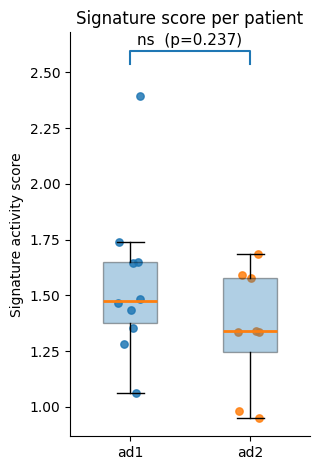

(   patient  mean_signature_score group
 0      P02              1.646744   ad1
 1      P10              1.283901   ad1
 2      P11              1.740436   ad1
 3      P13              1.465560   ad1
 4      P17              1.650972   ad1
 5      P18              2.394953   ad1
 6      P23              1.355121   ad1
 7      P24              1.061533   ad1
 8      P26              1.434026   ad1
 9      P32              1.484224   ad1
 10     P19              1.687838   ad2
 11     P25              1.335375   ad2
 12     P27              0.951032   ad2
 13     P28              0.982533   ad2
 14     P29              1.341870   ad2
 15     P30              1.591288   ad2
 16     P33              1.335606   ad2
 17     P36              1.575975   ad2,
   group  n_patients  mean_of_patient_means  median_of_patient_means  \
 0   ad1          10               1.551747                 1.474892   
 1   ad2           8               1.350190                 1.338738   
 
    mannwhitney_pvalu

In [31]:
# comparing PFS > 6 months and PFS < 6 months, new activated CD8s on per patient basis
activation_score = ['CXCL13','IFNG','ENTPD1','GZMA']
ad1= adata16[("responder", "new_D15", "activated")]
ad2= adata16[("nonresponder", "new_D15", "activated")]

per_patient_scores, summary = plot_signature_by_patient_two_adatas(
    ad1, ad2,
    genes=activation_score,
    group_names=("ad1", "ad2"),
    use_raw=False,          # set True only if .raw exists
    specimen_col="specimenID",
    figsize=(3.3, 4.8),
)

per_patient_scores, summary

# Fig S4E

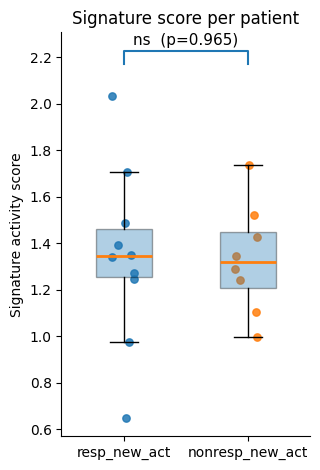

In [42]:
# comparing PFS > 6 months and PFS < 6 months, persisting activated CD8s on per patient basis
ad1 = adata16[("responder", "persisting_D15", "activated")]
ad2 = adata16[("nonresponder", "persisting_D15", "activated")]

activation_score = ['CXCL13','IFNG','ENTPD1','GZMA']
per_patient_scores, summary = plot_signature_by_patient_two_adatas(
    ad1, ad2,
    genes=activation_score,
    group_names=("resp_new_act", "nonresp_new_act"),
    use_raw=False,          # set True only if .raw exists
    specimen_col="specimenID",
    figsize=(3.3, 4.8),
)

per_patient_scores, summary

per_patient_scores.to_csv("activation_signature_R_vs_NR_persis_act_CD8_summary.csv", index=False)


# Fig 4F

In [33]:
# Repeating some of the TCR merging with CD8 post label transfer dataframe

meta_intra_tcr = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/bulk_blood_TCRs/meta_combos/all_intra_clones_t.csv', sep = ',')
cd8_post_label_transfer = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/HC_Tclus/cd8_post_label_transfer.csv', sep = ',')

def splice_id(df):
    df['cell_id'] = df['cell_id'].str.split('-').str[0]
    return df
cd8_post_lt_meta = (splice_id(cd8_post_label_transfer))

CD8_matching_cells_post_lt = pd.merge(
    cd8_post_lt_meta,
    meta_intra_tcr,
    left_on=['cell_id', 'specimenID'],  # Columns from cd8_post_lt_meta
    right_on=['barcode', 'patient 10x channel'],  # Columns from meta_intra_tcr
    how='inner'
)

cd8_post_lt_pre = CD8_matching_cells_post_lt[CD8_matching_cells_post_lt['treatment'] == 'Pre']
cd8_post_lt_on = CD8_matching_cells_post_lt[CD8_matching_cells_post_lt['treatment'] == 'On']


cd8_post_lt_g6 = CD8_matching_cells_post_lt[CD8_matching_cells_post_lt['PFSmo'] > 6]
cd8_post_lt_l6 = CD8_matching_cells_post_lt[CD8_matching_cells_post_lt['PFSmo'] <= 6]

cd8_g6_pre_post_lt =  cd8_post_lt_pre[cd8_post_lt_pre['PFSmo'] > 6]
cd8_g6_on_post_lt = cd8_post_lt_on[cd8_post_lt_on['PFSmo'] > 6]
cd8_l6_pre_post_lt = cd8_post_lt_pre[cd8_post_lt_pre['PFSmo'] <= 6]
cd8_l6_on_post_lt = cd8_post_lt_on[cd8_post_lt_on['PFSmo'] <= 6]

cd8_post_lt_g6_filtered = cd8_post_lt_g6[cd8_post_lt_g6['transferCd8tCellType'].isin([4, 7, 8])]
cd8_post_lt_l6_filtered = cd8_post_lt_l6[cd8_post_lt_l6['transferCd8tCellType'].isin([4, 7, 8])]

cd8_g6_pre_post_lt_filtered = cd8_g6_pre_post_lt[cd8_g6_pre_post_lt['transferCd8tCellType'].isin([4, 7, 8])]
cd8_g6_on_post_lt_filtered = cd8_g6_on_post_lt[cd8_g6_on_post_lt['transferCd8tCellType'].isin([4, 7, 8])]
cd8_l6_pre_post_lt_filtered = cd8_l6_pre_post_lt[cd8_l6_pre_post_lt['transferCd8tCellType'].isin([4, 7, 8])]
cd8_l6_on_post_lt_filtered = cd8_l6_on_post_lt[cd8_l6_on_post_lt['transferCd8tCellType'].isin([4, 7, 8])]

target_clusters = [4, 7, 8]

# List of CD8 filtered dataframes to apply the filtering
cd8_filtered_dfs = [
    cd8_post_lt_g6_filtered,
    cd8_post_lt_l6_filtered,
    cd8_g6_pre_post_lt_filtered,
    cd8_g6_on_post_lt_filtered,
    cd8_l6_pre_post_lt_filtered,
    cd8_l6_on_post_lt_filtered
]

# Apply the CDR3_beta sequence filtering to each CD8 dataframe
cd8_filtered_with_cdr3 = []
for df in cd8_filtered_dfs:
    # Step 1: Group by CDR3_beta sequence and count cells for each sequence
    cdr3_counts = df.groupby('CDR3_beta sequence').size()
    
    # Step 2: Filter for CDR3_beta sequences with at least 3 cells
    valid_cdr3_sequences = cdr3_counts[cdr3_counts >= 3].index
    
    # Step 3: Filter sequences where more than half of the cells are in clusters 4, 7, or 8
    filtered_sequences = []
    for cdr3 in valid_cdr3_sequences:
        sequence_cells = df[df['CDR3_beta sequence'] == cdr3]
        cluster_cells_count = sequence_cells[sequence_cells['transferCd8tCellType'].isin(target_clusters)].shape[0]
        total_cells_count = sequence_cells.shape[0]
        
        if cluster_cells_count > total_cells_count / 2:
            filtered_sequences.append(cdr3)
    
    # Step 4: Filter the original dataframe to include only rows with valid CDR3_beta sequences
    df_filtered = df[df['CDR3_beta sequence'].isin(filtered_sequences)]
    cd8_filtered_with_cdr3.append(df_filtered)

# Now, cd8_filtered_with_cdr3 contains each filtered dataframe with the additional CDR3_beta criteria applied

cd8_post_lt_g6_filtered = cd8_filtered_with_cdr3[0]
cd8_post_lt_l6_filtered = cd8_filtered_with_cdr3[1]
cd8_g6_pre_post_lt_filtered = cd8_filtered_with_cdr3[2]
cd8_g6_on_post_lt_filtered = cd8_filtered_with_cdr3[3]
cd8_l6_pre_post_lt_filtered = cd8_filtered_with_cdr3[4]
cd8_l6_on_post_lt_filtered = cd8_filtered_with_cdr3[5]
print(cd8_g6_pre_post_lt_filtered)

       Unnamed: 0           cell_id orig.ident  nCount_RNA  nFeature_RNA  idx  \
86            122  TAGTGGTTCGCTTAGA        CRC        2013           853    9   
895          1324  AACGTTGGTAGGGACT        CRC        3245          1284    1   
916          1442  CTCGTCAGTCTCACCT        CRC        1318           811    1   
928          1495  GGACAGACAATAGCGG        CRC        3555          1456    1   
931          1509  GTAACGTTCGGTTCGG        CRC        2633          1031    1   
...           ...               ...        ...         ...           ...  ...   
26895       39314  ACGGGCTTCAGGATCT        CRC        7341          2571   47   
26898       39317  CGGACTGTCCACGAAT        CRC        5042          1968   47   
26899       39318  CGTCAGGCATCCGGGT        CRC        4978          2050   47   
26900       39319  GTGCATAGTAACGCGA        CRC        4454          1769   47   
31994       45824  GGCTCGACACGAAATA        CRC        1509           854   46   

      sampleID specimenID p

In [40]:
# now, moving to blood, doing some patient specific looks at top clones 
# Firstly blood TCRs were manually organized by organizing all the bulk blood TCR beta sequences for all patients 
# Here, we focus on P18 a patient with PFS > 6 months.
g6_blood_tcr = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/bulk_blood_TCRs/meta_combos/PFS_g6_meta_blood_clones_071924.csv', sep = ',')

/tmp/ipykernel_119/3314534603.py:4: DtypeWarning: Columns (0,3,4,5,6,8,11,12,13,16,19,20,21,24,27,28,29,32,35,36,37,40,43,44,45,48,51,52,53,56,59,60,61,62,64,67,68,69,70,71,72,75,76,77,80,83,84,85) have mixed types. Specify dtype option on import or set low_memory=False.
  g6_blood_tcr = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/bulk_blood_TCRs/meta_combos/PFS_g6_meta_blood_clones_071924.csv', sep = ',')


In [37]:
# Define the cycle columns, one can imagine very similar code for patients with PFS < 6 months
cycle_columns = ['p02_cycle', 'p10_cycle', 'p11_cycle', 'p13_cycle',
                 'p17_cycle', 'p18_cycle', 'p20_cycle', 'p23_cycle', 
                 'p24_cycle', 'p26_cycle', 'p32_cycle']

# Creating 11 separate dataframes
p02_df = g6_blood_tcr[g6_blood_tcr['p02_cycle'].notna()]
p10_df = g6_blood_tcr[g6_blood_tcr['p10_cycle'].notna()]
p11_df = g6_blood_tcr[g6_blood_tcr['p11_cycle'].notna()]
p13_df = g6_blood_tcr[g6_blood_tcr['p13_cycle'].notna()]
p17_df = g6_blood_tcr[g6_blood_tcr['p17_cycle'].notna()]
p18_df = g6_blood_tcr[g6_blood_tcr['p18_cycle'].notna()]
p20_df = g6_blood_tcr[g6_blood_tcr['p20_cycle'].notna()]
p23_df = g6_blood_tcr[g6_blood_tcr['p23_cycle'].notna()]
p24_df = g6_blood_tcr[g6_blood_tcr['p24_cycle'].notna()]
p26_df = g6_blood_tcr[g6_blood_tcr['p26_cycle'].notna()]
p32_df = g6_blood_tcr[g6_blood_tcr['p32_cycle'].notna()]

distinct_p18_cycles = p18_df['p18_cycle'].drop_duplicates()

# Print the distinct value
print("Distinct values of p18_cycle:")
print(distinct_p18_cycles.tolist())  # Convert to list for a cleaner output

Distinct values of p18_cycle:
['P18C1D1', 'P18C1D15', 'P18C3D1', 'P18C4D1', 'P18C5D1', 'P18C11D1', 'P18C13D1']


In [38]:
# function for finding top CDR3 matches between the intratumoral TCR sequencing and the bulk blood TCR sequencing
# matching on the TCR beta sequence
def find_top_cdr3_matches(specimenID_call, patient_cycle_df, cd8_g6_pre_post_lt_filtered):
    filtered_cd8 = cd8_g6_pre_post_lt_filtered[cd8_g6_pre_post_lt_filtered['specimenID'] == specimenID_call]
    
    if filtered_cd8.empty:
        print(f"No data found for specimenID: {specimenID_call}")
        return pd.DataFrame()  # Return an empty DataFrame
    
    # Get top 25 most frequent CDR3 sequences
    top_25_cdr3 = (filtered_cd8['CDR3_beta sequence']
                   .value_counts()  # Get frequency counts of CDR3_beta
                   .nlargest(25)  # Take top 25 most frequent
                   .index.tolist())  # Get the sequence names
    
    # Filter the patient_cycle_df for matching CDR3 sequences
    matching_cdr3 = patient_cycle_df[patient_cycle_df['p18_CDR3'].isin(top_25_cdr3)]
    
    if not matching_cdr3.empty: 
        # Calculate the fraction of UMI_per_clone / total UMIs for this specific patient cycle
        matching_cdr3.loc[:, 'UMI_fraction'] = matching_cdr3['p18_freq']
        
        # Create a result dataframe with the CDR3_beta sequence, UMI fraction, and p24_cycle
        result_df = matching_cdr3[['p18_CDR3', 'UMI_fraction', 'p18_cycle']].copy()  # Include p24_cycle
        
        # Print out the resulting dataframe
        print(f"Matches found for specimenID: {specimenID_call}")
        return result_df  # Return the result DataFrame
    else:
        print(f"No CDR3 matches found for specimenID: {specimenID_call}")
        return pd.DataFrame()  # Return an empty DataFrame

# Example usage
res = find_top_cdr3_matches(specimenID_call='P18D15', 
                      patient_cycle_df=p18_df,  # Pass the appropriate dataframe for 'p24'
                      cd8_g6_pre_post_lt_filtered=cd8_g6_on_post_lt_filtered)

# Now call the plotting function
print(res)

Matches found for specimenID: P18D15
                p18_CDR3  UMI_fraction p18_cycle
19685     CASSGVGVVGEAFF      0.000753  P18C1D15
19737     CASSTPGTQYEQYF      0.000355  P18C1D15
19764       CASSTYSYGYTF      0.000284  P18C1D15
19846     CSVVSGGPYNEQFF      0.000185  P18C1D15
19896   CASSRHRTGNNYGYTF      0.000142  P18C1D15
20126   CAISDRGHSSSYEQYF      0.000085  P18C1D15
20223       CASSYERVRQFF      0.000085  P18C1D15
20416    CASSVGDFSSYEQYF      0.000071  P18C1D15
20708      CASSQGGGTEAFF      0.000057  P18C1D15
23411     CASSLISSTDTQYF      0.000028  P18C1D15
23943     CASSPGTAVSGYTF      0.000028  P18C1D15
24038     CASSPPDREETQYF      0.000028  P18C1D15
25526    CATSEFTGQGETQYF      0.000028  P18C1D15
29043       CASQDRADTQYF      0.000014  P18C1D15
35617    CASSIATGSYNEQFF      0.000014  P18C1D15
49112   CASSQPGGSETDTQYF      0.000014  P18C1D15
52097    CASSSLAGGGYEQFF      0.000014  P18C1D15
63042     CSVGLADRTGELFF      0.000014  P18C1D15
63461         CSVRQGGYTF      0.

/tmp/ipykernel_119/2106445682.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matching_cdr3.loc[:, 'UMI_fraction'] = matching_cdr3['p18_freq']


In [39]:
# saving as CSV and ordering the columns chronologically across the cycles
def save_cdr3_frequency_as_csv(res, name):
    # Ensure the result DataFrame is not empty
    if res is None or res.empty:
        print("No data to process.")
        return

    # Define the specific chronological order for p18_cycle with "P2" prefix
    cycle_order = ['P18C1D1', 'P18C1D15', 'P18C3D1', 'P18C4D1', 'P18C5D1', 'P18C11D1', 'P18C13D1']

    # Convert p18_cycle to a categorical type with ordered categories
    res['p18_cycle'] = pd.Categorical(res['p18_cycle'].astype(str), categories=cycle_order, ordered=True)

    # Drop NaN values from 'p18_cycle'
    res = res.dropna(subset=['p18_cycle'])

    # Create a pivot table with CDR3 sequences as rows and cycles as columns
    pivot_df = res.pivot_table(index='p18_CDR3', columns='p18_cycle', values='UMI_fraction', aggfunc='mean').fillna(0)

    # Reorder the columns to match the specified cycle_order
    pivot_df = pivot_df.reindex(columns=cycle_order, fill_value=0)

    # Save the pivot table to a CSV file
    pivot_df.to_csv(name + '.csv', index=True)  # Save with provided name
    print(f"CDR3 frequency data has been saved to {name}.csv")
    print(pivot_df)
    # Print out the CDR3 sequences line by line
    print("\nCDR3 sequences:")
    for cdr3 in pivot_df.index:
        print(cdr3)

# Example usage
save_cdr3_frequency_as_csv(res, name='P18D15_act_CD8_blood')


CDR3 frequency data has been saved to P18D15_act_CD8_blood.csv
p18_cycle         P18C1D1  P18C1D15   P18C3D1   P18C4D1  P18C5D1  P18C11D1  \
p18_CDR3                                                                     
CAISDRGHSSSYEQYF        0  0.000085  0.000000  0.000000  0.00000         0   
CASQDRADTQYF            0  0.000014  0.000000  0.000090  0.00000         0   
CASSGVGVVGEAFF          0  0.000753  0.000025  0.000000  0.00002         0   
CASSIATGSYNEQFF         0  0.000014  0.000000  0.000000  0.00002         0   
CASSLISSTDTQYF          0  0.000028  0.000000  0.000000  0.00000         0   
CASSPGTAVSGYTF          0  0.000028  0.000000  0.000000  0.00000         0   
CASSPPDREETQYF          0  0.000028  0.000000  0.000000  0.00005         0   
CASSQGGGTEAFF           0  0.000057  0.000000  0.000000  0.00002         0   
CASSQPGGSETDTQYF        0  0.000014  0.000000  0.000000  0.00003         0   
CASSRHRTGNNYGYTF        0  0.000142  0.000025  0.000000  0.00002         0   
C

# Fig S4F-G

In [46]:
# Bulk blood TCRs from all patients (firstly, patients with PFS > 6 mo) and calculate gini coeffcient 
g6_blood_tcr = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/bulk_blood_TCRs/meta_combos/PFS_g6_meta_blood_clones_071924.csv', sep = ',')
df = g6_blood_tcr 

def gini_coefficient(arr):
    if len(arr) == 0:
        return np.nan
    sorted_arr = np.sort(arr)
    n = len(arr)
    cumulative_values = np.cumsum(sorted_arr)
    return 1 - 2 * np.sum(cumulative_values) / (n * np.sum(sorted_arr)) + 1 / n

cycle_columns = ['p02_cycle', 'p10_cycle', 'p11_cycle', 'p13_cycle',
                 'p17_cycle', 'p18_cycle', 'p20_cycle', 'p23_cycle', 
                 'p24_cycle', 'p26_cycle', 'p32_cycle']
value_columns = ['p02_UMI_per_clone', 'p10_UMI_per_clone', 'p11_UMI_per_clone', 'p13_UMI_per_clone',
                 'p17_UMI_per_clone', 'p18_UMI_per_clone', 'p20_UMI_per_clone', 'p23_UMI_per_clone', 
                 'p24_UMI_per_clone', 'p26_UMI_per_clone', 'p32_UMI_per_clone']
gini_results = []

for i, cycle_col in enumerate(cycle_columns):
    value_col = value_columns[i]
    distinct_cycles = df[cycle_col].dropna().unique()
    
    for cycle in distinct_cycles:
        filtered_rows = df[df[cycle_col] == cycle]
        values = pd.to_numeric(filtered_rows[value_col], errors='coerce').dropna().values
        if len(values) > 0:
            gini = gini_coefficient(values)
            gini_results.append([cycle_col, cycle, gini])
        else:
            gini_results.append([cycle_col, cycle, np.nan])

gini_df = pd.DataFrame(gini_results, columns=['Cycle Column', 'Cycle', 'Gini Coefficient'])
print(gini_df)


# same functions pretty much below, can look at per patient at specific time point 
def gini_coefficient(arr):
    if len(arr) == 0:
        return np.nan
    sorted_arr = np.sort(arr)
    n = len(arr)
    cumulative_values = np.cumsum(sorted_arr)
    return 1 - 2 * np.sum(cumulative_values) / (n * np.sum(sorted_arr)) + 1 / n

cycle_columns = ['p02_cycle', 'p10_cycle', 'p11_cycle', 'p13_cycle',
                 'p17_cycle', 'p18_cycle', 'p20_cycle', 'p23_cycle', 
                 'p24_cycle', 'p26_cycle', 'p32_cycle']
value_columns = ['p02_UMI_per_clone', 'p10_UMI_per_clone', 'p11_UMI_per_clone', 'p13_UMI_per_clone',
                 'p17_UMI_per_clone', 'p18_UMI_per_clone', 'p20_UMI_per_clone', 'p23_UMI_per_clone', 
                 'p24_UMI_per_clone', 'p26_UMI_per_clone', 'p32_UMI_per_clone']
gini_results = []

valid_endings = ['C2D15'] 
#                  'C1D15','C2D1']

for i, cycle_col in enumerate(cycle_columns):
    value_col = value_columns[i]
    distinct_cycles = df[cycle_col].dropna().unique()
    
    for cycle in distinct_cycles:
        if cycle.endswith(tuple(valid_endings)):  # Filter for cycles ending in 'C1D1' or 'C2D1'
            filtered_rows = df[df[cycle_col] == cycle]
            values = pd.to_numeric(filtered_rows[value_col], errors='coerce').dropna().values
            if len(values) > 0:
                gini = gini_coefficient(values)
                gini_results.append([cycle_col, cycle, gini])
            else:
                gini_results.append([cycle_col, cycle, np.nan])

gini_df = pd.DataFrame(gini_results, columns=['Cycle Column', 'Cycle', 'Gini Coefficient'])
print(gini_df)
print(gini_df['Gini Coefficient'])
gini_coefficients_list = gini_df['Gini Coefficient'].tolist()
print(gini_coefficients_list)
for i in gini_coefficients_list:
    print(i)
    

def gini_coefficient(arr):
    if len(arr) == 0:
        return np.nan
    sorted_arr = np.sort(arr)
    n = len(arr)
    cumulative_values = np.cumsum(sorted_arr)
    return 1 - 2 * np.sum(cumulative_values) / (n * np.sum(sorted_arr)) + 1 / n

cycle_columns = ['p03_cycle', 'p14_cycle', 'p15_cycle', 'p19_cycle',
                 'p25_cycle', 'p27_cycle', 'p28_cycle', 'p29_cycle']
value_columns = ['p03_UMI_per_clone', 'p14_UMI_per_clone', 'p15_UMI_per_clone', 'p19_UMI_per_clone',
                 'p25_UMI_per_clone', 'p27_freq', 'p28_freq', 'p29_UMI_per_clone']
gini_results = []

valid_endings = ['C5D1'] 
#                  'C1D15','C2D1']

for i, cycle_col in enumerate(cycle_columns):
    value_col = value_columns[i]
    distinct_cycles = df2[cycle_col].dropna().unique()
    
    for cycle in distinct_cycles:
        if cycle.endswith(tuple(valid_endings)):  # Filter for cycles ending in 'C1D1' or 'C2D1'
            filtered_rows = df2[df2[cycle_col] == cycle]
            values = pd.to_numeric(filtered_rows[value_col], errors='coerce').dropna().values
            if len(values) > 0:
                gini = gini_coefficient(values)
                gini_results.append([cycle_col, cycle, gini])
            else:
                gini_results.append([cycle_col, cycle, np.nan])

gini_df = pd.DataFrame(gini_results, columns=['Cycle Column', 'Cycle', 'Gini Coefficient'])
print(gini_df)
gini_coefficients_list = gini_df['Gini Coefficient'].tolist()
print(gini_coefficients_list)
for i in gini_coefficients_list:
    print(i)

/tmp/ipykernel_119/3880824059.py:2: DtypeWarning: Columns (0,3,4,5,6,8,11,12,13,16,19,20,21,24,27,28,29,32,35,36,37,40,43,44,45,48,51,52,53,56,59,60,61,62,64,67,68,69,70,71,72,75,76,77,80,83,84,85) have mixed types. Specify dtype option on import or set low_memory=False.
  g6_blood_tcr = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/bulk_blood_TCRs/meta_combos/PFS_g6_meta_blood_clones_071924.csv', sep = ',')


   Cycle Column    Cycle  Gini Coefficient
0     p02_cycle   P2C1D1          0.225913
1     p02_cycle   P2C2D1          0.325645
2     p02_cycle   P2C3D1          0.292013
3     p02_cycle   P2C4D1          0.265163
4     p02_cycle   P2C5D1          0.379309
..          ...      ...               ...
87    p32_cycle  P32C1D1          0.378523
88    p32_cycle  P32C2D1          0.451274
89    p32_cycle  P32C3D1          0.455313
90    p32_cycle  P32C4D1          0.448898
91    p32_cycle  P32C5D1          0.407098

[92 rows x 3 columns]
  Cycle Column     Cycle  Gini Coefficient
0    p23_cycle  P23C2D15          0.414132
0    0.414132
Name: Gini Coefficient, dtype: float64
[0.41413158825610186]
0.41413158825610186


In [51]:
# Bulk blood TCRs from all patients (secdonly, patients with PFS < 6 mo) and calculate gini coeffcient 
l6_blood_tcr_1 = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/bulk_blood_TCRs/meta_combos/PFS_l6_meta_blood_clones_03to29.csv', sep = ',')
l6_blood_tcr_2 = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/bulk_blood_TCRs/meta_combos/PFS_l6_meta_blood_clones_P30rest.csv', sep = ',')
df2 = l6_blood_tcr_1
df3 = l6_blood_tcr_2


def gini_coefficient(arr):
    if len(arr) == 0:
        return np.nan
    sorted_arr = np.sort(arr)
    n = len(arr)
    cumulative_values = np.cumsum(sorted_arr)
    return 1 - 2 * np.sum(cumulative_values) / (n * np.sum(sorted_arr)) + 1 / n

cycle_columns = ['p03_cycle', 'p14_cycle', 'p15_cycle', 'p19_cycle',
                 'p25_cycle', 'p27_cycle', 'p28_cycle', 'p29_cycle']
value_columns = ['p03_UMI_per_clone', 'p14_UMI_per_clone', 'p15_UMI_per_clone', 'p19_UMI_per_clone',
                 'p25_UMI_per_clone', 'p27_freq', 'p28_freq', 'p29_UMI_per_clone']
gini_results = []

valid_endings = ['C5D1'] 
#                  'C1D15','C2D1']

for i, cycle_col in enumerate(cycle_columns):
    value_col = value_columns[i]
    distinct_cycles = df2[cycle_col].dropna().unique()
    
    for cycle in distinct_cycles:
        if cycle.endswith(tuple(valid_endings)):  # Filter for cycles ending in 'C1D1' or 'C2D1'
            filtered_rows = df2[df2[cycle_col] == cycle]
            values = pd.to_numeric(filtered_rows[value_col], errors='coerce').dropna().values
            if len(values) > 0:
                gini = gini_coefficient(values)
                gini_results.append([cycle_col, cycle, gini])
            else:
                gini_results.append([cycle_col, cycle, np.nan])

gini_df = pd.DataFrame(gini_results, columns=['Cycle Column', 'Cycle', 'Gini Coefficient'])
print(gini_df)
gini_coefficients_list = gini_df['Gini Coefficient'].tolist()
print(gini_coefficients_list)
for i in gini_coefficients_list:
    print(i)
    

def gini_coefficient(arr):
    if len(arr) == 0:
        return np.nan
    sorted_arr = np.sort(arr)
    n = len(arr)
    cumulative_values = np.cumsum(sorted_arr)
    return 1 - 2 * np.sum(cumulative_values) / (n * np.sum(sorted_arr)) + 1 / n

cycle_columns = ['p30_cycle', 'p33_cycle', 'p35_cycle', 'p36_cycle']
value_columns = ['p30_freq', 'p33_freq', 'p35_freq', 'p36_freq']  # Updated column names
gini_results = []

valid_endings = ['C5D1'] 
#                  'C1D15','C2D1']

for i, cycle_col in enumerate(cycle_columns):
    value_col = value_columns[i]
    distinct_cycles = df3[cycle_col].dropna().unique()
    
    for cycle in distinct_cycles:
        if cycle.endswith(tuple(valid_endings)):  # Filter for cycles ending in 'C1D1' or 'C2D1'
            filtered_rows = df3[df3[cycle_col] == cycle]
            values = pd.to_numeric(filtered_rows[value_col], errors='coerce').dropna().values
            if len(values) > 0:
                gini = gini_coefficient(values)
                gini_results.append([cycle_col, cycle, gini])
            else:
                gini_results.append([cycle_col, cycle, np.nan])

gini_df = pd.DataFrame(gini_results, columns=['Cycle Column', 'Cycle', 'Gini Coefficient'])
print(gini_df)
gini_coefficients_list = gini_df['Gini Coefficient'].tolist()
print(gini_coefficients_list)
for i in gini_coefficients_list:
    print(i)

/tmp/ipykernel_119/2663182416.py:2: DtypeWarning: Columns (0,3,4,5,8,11,12,13,16,19,20,21,24,27,28,29,32,35,36,37,38,48,51,52,53,56,59,60,61) have mixed types. Specify dtype option on import or set low_memory=False.
  l6_blood_tcr_1 = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/bulk_blood_TCRs/meta_combos/PFS_l6_meta_blood_clones_03to29.csv', sep = ',')
/tmp/ipykernel_119/2663182416.py:3: DtypeWarning: Columns (0,3,4,5,8,11,12,13,24,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  l6_blood_tcr_2 = pd.read_csv('gs://fc-e9295d8f-5730-4967-b1ce-22c3d775d7c2/bulk_blood_TCRs/meta_combos/PFS_l6_meta_blood_clones_P30rest.csv', sep = ',')


  Cycle Column    Cycle  Gini Coefficient
0    p19_cycle  P19C5D1          0.677702
1    p28_cycle  P28C5D1          0.397351
[0.6777021441119665, 0.3973510378852864]
0.6777021441119665
0.3973510378852864
Empty DataFrame
Columns: [Cycle Column, Cycle, Gini Coefficient]
Index: []
[]
